In [37]:
from real_time_weather_ingestion import main_scrapper
from radar_image_processor import image_to_possible_storm
from datetime import datetime 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [84]:
# pull dummy data to work with
# ts_str = '202510091010'
current_datetime = datetime(2025,10,9,10,10,0)
run_datetime= current_datetime.replace(minute = 10,second = 0, microsecond=0).isoformat()

dummy_data = main_scrapper(run_datetime)
dummy_data

# humidity_df = humidity_api(run_datetime)
# temperature_df = temperature_api(run_datetime)
# wind_speed_df = wind_speed_api(run_datetime)
# wind_direction_df = wind_direction_api(run_datetime)
# rainfall_df = rainfall_api(run_datetime)


,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6


In [85]:
station_pixels = [
    ('S111', (102, 71)),   # Northwest – near Woodlands / Kranji area
    ("S107", (175, 25)),  # Northeast – near Pasir Ris / Changi North
    ("S109", (35, 95)),  # Southwest – near Jurong / Tuas
    ("S44", (101, 71)) # Southeast – near Changi Airport / East Coast
]

station_df = pd.DataFrame(station_pixels)
station_df.rename(columns={0:'station_id',1:'coord'},inplace=True)
station_df

,station_id,coord
0,S111,"(102, 71)"
1,S107,"(175, 25)"
2,S109,"(35, 95)"
3,S44,"(101, 71)"


In [86]:
dummy_data = dummy_data.merge(station_df, on = 'station_id' , how = 'left')
dummy_data

,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,coord
0,2025-10-09T10:10:00,S109,273,13.5,0.2,23.4,90.2,"(35, 95)"
1,2025-10-09T10:10:00,S106,273,5.0,0.0,26.7,80.8,NaN
2,2025-10-09T10:10:00,S117,290,4.7,0.0,24.1,90.8,NaN
3,2025-10-09T10:10:00,S107,251,13.7,0.0,26.4,75.5,"(175, 25)"
4,2025-10-09T10:10:00,S115,274,5.5,0.4,24.5,97.4,NaN
5,2025-10-09T10:10:00,S60,277,8.7,0.0,23.9,85.2,NaN
6,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,"(101, 71)"
7,2025-10-09T10:10:00,S43,274,7.6,1.8,23.7,91.6,NaN
8,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,"(102, 71)"


In [28]:
with open('sample_data/test_image.jpg','rb') as f:
    data = f.read()

In [32]:
possible_storm_grid, possible_storm_df = image_to_possible_storm(data,50,80)

/Users/javier/VSCODE/local/DSA3101_vsc/dsa3101_final_project/DSA3101_storm_4/backend/storm_object_detector/radar_image_processor.py:47: RuntimeWarning: invalid value encountered in sqrt
  d  = np.sqrt(d2, dtype=np.float32)


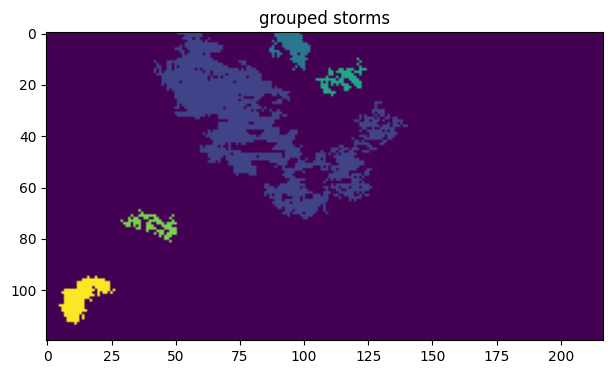

In [34]:
plt.figure(figsize=(8,4))           
plt.imshow(possible_storm_grid)      
plt.title("grouped storms")
plt.show()

In [35]:
possible_storm_df

,new_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x
0,1,2009,68.0,36.0,83.0,35.76,82.83
1,2,125,68.0,5.0,96.0,5.50,95.50
2,3,95,68.0,18.0,115.0,17.88,114.91
3,4,89,62.0,75.0,41.0,74.64,41.36
4,5,178,68.0,103.0,14.0,102.81,13.60


In [105]:
def storm_pixel_coordinates(
        storm_id
        ,full_storm_grid
): 
        # binary mask 
        storm_mask = (full_storm_grid == storm_id).astype(np.uint8)

        #print(int(storm_mask.sum()))

        # return coordinates for every pixel 
        ys,xs = np.where(storm_mask)

        # pack into dataframe 
        coord = list(zip(xs,ys))
        df = pd.DataFrame({'coord':coord})

        return df

def metric_threshold_calc(
        input_df
        ,wind_speed_threshold
        ,rainfall_threshold
        ,temperature_threshold
        ,humidty_threshold
): 
        res = False
        threshold_flags = [False,False,False,False]

        # if single station 
        if input_df.shape[0] == 1: 
                if input_df['wind_speed_knots'] >= wind_speed_threshold:
                        threshold_flags[0] = True
                if input_df['rainfall_mm'] >= rainfall_threshold:
                        threshold_flags[1] = True
                if input_df['temperature_c'] >= temperature_threshold:
                        threshold_flags[2] = True
                if input_df['humidity_pct'] >= humidty_threshold:
                        threshold_flags[3] = True


        # if multi station, average all 
        else:
                cols_to_avg = ["wind_speed_knots", "rainfall_mm", "temperature_c", "humidity_pct"]
                mean_df = input_df[cols_to_avg].mean()

                if mean_df['wind_speed_knots'] >= wind_speed_threshold:
                        threshold_flags[0] = True
                if mean_df['rainfall_mm'] >= rainfall_threshold:
                        threshold_flags[1] = True
                if mean_df['temperature_c'] <= temperature_threshold:
                        threshold_flags[2] = True
                if mean_df['humidity_pct'] >= humidty_threshold:
                        threshold_flags[3] = True

        if sum(threshold_flags) == 4:
                res = True
        return res


def storm_object_checker(
        storm_id
        ,possible_storm_grid

        ,weather_data_df

        # threshholds 
        ,wind_speed_threshold
        ,rainfall_threshold
        ,temperature_threshold
        ,humidty_threshold
): 
        curr_storm = storm_pixel_coordinates(storm_id, possible_storm_grid)

        nearby_stations = pd.merge(weather_data_df,curr_storm,how='inner' , on = 'coord')

        res = metric_threshold_calc(nearby_stations,wind_speed_threshold,rainfall_threshold,temperature_threshold,humidty_threshold)
        
        return res


In [98]:
# take in grid and df, for each storm pull grid for that storm 
# then pull xy coord for every pixel in that storm 
# then check if it contains any of the station data 

test_storm= storm_pixel_coordinates(1,possible_storm_grid)
test_storm


contain_station = pd.merge(dummy_data,test_storm ,how = 'inner', on = 'coord')
contain_station

# metrics above threshold 
# pull first 




,time_stamp,station_id,wind_direction_degrees,wind_speed_knots,rainfall_mm,temperature_c,humidity_pct,coord
0,2025-10-09T10:10:00,S44,359,6.5,0.4,22.6,99.1,"(101, 71)"
1,2025-10-09T10:10:00,S111,225,12.0,3.4,21.3,98.6,"(102, 71)"


In [102]:
above = metric_threshold_calc(contain_station,5,1,25,90)
above


True

In [103]:
test= possible_storm_df['new_id'].unique().tolist()
test

[1, 2, 3, 4, 5]

In [104]:
test = possible_storm_df

In [106]:
test['output'] = test['new_id'].apply(lambda x: storm_object_checker(x,possible_storm_grid,dummy_data,5,1,25,90))
test

,new_id,area_px,peak_dbz,anchor_y,anchor_x,centroid_y,centroid_x,output
0,1,2009,68.0,36.0,83.0,35.76,82.83,True
1,2,125,68.0,5.0,96.0,5.50,95.50,False
2,3,95,68.0,18.0,115.0,17.88,114.91,False
3,4,89,62.0,75.0,41.0,74.64,41.36,False
4,5,178,68.0,103.0,14.0,102.81,13.60,False
